# 9.5.机器翻译与数据集

语言模型是自然语言处理的关键， 而*机器翻译*是语言模型最成功的基准测试。 因为机器翻译正是将输入序列转换成输出序列的 *序列转换模型*（sequence transduction）的核心问题。 序列转换模型在各类现代人工智能应用中发挥着至关重要的作用， 因此我们将其作为本章剩余部分和第10章的重点。 为此，本节将介绍机器翻译问题及其后文需要使用的数据集。

*机器翻译*（machine translation）指的是 将序列从一种语言自动翻译成另一种语言。 事实上，这个研究领域可以追溯到数字计算机发明后不久的20世纪40年代， 特别是在第二次世界大战中使用计算机破解语言编码。 几十年来，在使用神经网络进行端到端学习的兴起之前， 统计学方法在这一领域一直占据主导地位 ([Brown et al., 1990](https://zh.d2l.ai/chapter_references/zreferences.html#Brown.Cocke.Della-Pietra.ea.1988,Brown.Cocke.Della-Pietra.ea.1990))。 因为*统计机器翻译*（statistical machine translation）涉及了 翻译模型和语言模型等组成部分的统计分析， 因此基于神经网络的方法通常被称为 *神经机器翻译*（neural machine translation）， 用于将两种翻译模型区分开来。

本书的关注点是神经网络机器翻译方法，强调的是端到端的学习。 与 [8.3节](../08_pypto_recurrent_neural_networks/08.03_language_models_and_dataset.ipynb)中的语料库 是单一语言的语言模型问题存在不同， 机器翻译的数据集是由源语言和目标语言的文本序列对组成的。 因此，我们需要一种完全不同的方法来预处理机器翻译数据集， 而不是复用语言模型的预处理程序。 下面，我们看一下如何将预处理后的数据加载到小批量中用于训练。

---
## 9.5.1.环境配置

In [1]:
%pip install torch matplotlib

In [2]:
import torch
from src.utils import (read_data_nmt, preprocess_nmt, tokenize_nmt,
                        Vocab, truncate_pad, build_array_nmt,
                        load_data_nmt, show_list_len_pair_hist, load_array)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
import os
import torch
from d2l import torch as d2l
    </pre>

  </div>
</details>


---
## 9.5.2.下载和预处理数据集

首先，下载一个由[Tatoeba项目的双语句子对](http://www.manythings.org/anki/) 组成的“英－法”数据集，数据集中的每一行都是制表符分隔的文本序列对， 序列对由英文文本序列和翻译后的法语文本序列组成。 请注意，每个文本序列可以是一个句子， 也可以是包含多个句子的一个段落。 在这个将英语翻译成法语的机器翻译问题中， 英语是*源语言*（source language）， 法语是*目标语言*（target language）。

In [3]:
raw_text = read_data_nmt()
print(raw_text[:75])

Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !



<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
d2l.DATA_HUB['fra-eng'] = (d2l.DATA_URL + 'fra-eng.zip',
                           '94646ad1522d915e7b0f9296181140edcf86a4f5')

def read_data_nmt():
    """载入“英语－法语”数据集"""
    data_dir = d2l.download_extract('fra-eng')
    with open(os.path.join(data_dir, 'fra.txt'), 'r',
             encoding='utf-8') as f:
        return f.read()

raw_text = read_data_nmt()
print(raw_text[:75])
    </pre>

  </div>
</details>


下载数据集后，原始文本数据需要经过**几个预处理步骤**。 例如，我们用空格代替*不间断空格*（non-breaking space）， 使用小写字母替换大写字母，并在单词和标点符号之间插入空格。

In [4]:
text = preprocess_nmt(raw_text)
print(text[:80])

go .	va !
hi .	salut !
run !	cours !
run !	courez !
who ?	qui ?
wow !	ça alors !


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def preprocess_nmt(text):
    """预处理“英语－法语”数据集"""
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '

    # 使用空格替换不间断空格
    # 使用小写字母替换大写字母
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    # 在单词和标点符号之间插入空格
    out = [' ' + char if i &gt; 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)

text = preprocess_nmt(raw_text)
print(text[:80])
    </pre>

  </div>
</details>


---
## 9.5.3.词元化

与 [8.3节](../08_pypto_recurrent_neural_networks/08.03_language_models_and_dataset.ipynb)中的字符级词元化不同， 在机器翻译中，我们更喜欢单词级词元化 （最先进的模型可能使用更高级的词元化技术）。 下面的`tokenize_nmt`函数对前`num_examples`个文本序列对进行词元化， 其中每个词元要么是一个词，要么是一个标点符号。 此函数返回两个词元列表：`source`和`target`： `source[i]`是源语言（这里是英语）第$i$个文本序列的词元列表， `target[i]`是目标语言（这里是法语）第$i$个文本序列的词元列表。

In [5]:
source, target = tokenize_nmt(text)
source[:6], target[:6]

([['go', '.'],
  ['hi', '.'],
  ['run', '!'],
  ['run', '!'],
  ['who', '?'],
  ['wow', '!']],
 [['va', '!'],
  ['salut', '!'],
  ['cours', '!'],
  ['courez', '!'],
  ['qui', '?'],
  ['ça', 'alors', '!']])

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def tokenize_nmt(text, num_examples=None):
    """词元化“英语－法语”数据集"""
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i &gt; num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target

source, target = tokenize_nmt(text)
source[:6], target[:6]
    </pre>

  </div>
</details>


让我们**绘制每个文本序列所包含的词元数量的直方图**。 在这个简单的“英－法”数据集中，大多数文本序列的词元数量少于$20$个。

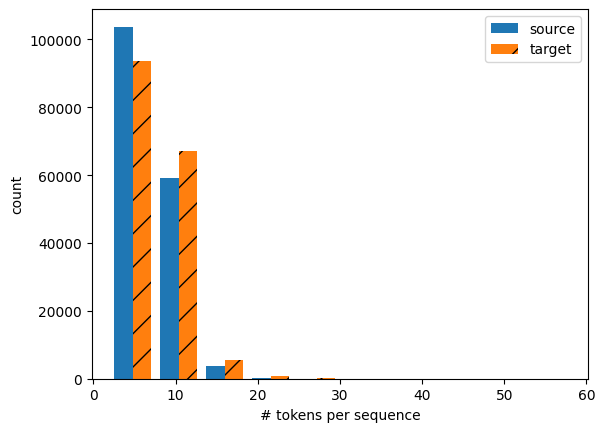

In [6]:
show_list_len_pair_hist(['source', 'target'], '# tokens per sequence',
                        'count', source, target)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def show_list_len_pair_hist(legend, xlabel, ylabel, xlist, ylist):
    """绘制列表长度对的直方图"""
    d2l.set_figsize()
    _, _, patches = d2l.plt.hist(
        [[len(l) for l in xlist], [len(l) for l in ylist]])
    d2l.plt.xlabel(xlabel)
    d2l.plt.ylabel(ylabel)
    for patch in patches[1].patches:
        patch.set_hatch('/')
    d2l.plt.legend(legend)

show_list_len_pair_hist(['source', 'target'], '# tokens per sequence',
                        'count', source, target);
    </pre>

  </div>
</details>


---
## 9.5.4.词表

由于机器翻译数据集由语言对组成， 因此我们可以分别为源语言和目标语言构建两个词表。 使用单词级词元化时，词表大小将明显大于使用字符级词元化时的词表大小。 为了缓解这一问题，这里我们将出现次数少于2次的低频率词元 视为相同的未知（“&lt;unk&gt;”）词元。 除此之外，我们还指定了额外的特定词元， 例如在小批量时用于将序列填充到相同长度的填充词元（“&lt;pad&gt;”）， 以及序列的开始词元（“&lt;bos&gt;”）和结束词元（“&lt;eos&gt;”）。 这些特殊词元在自然语言处理任务中比较常用。

In [7]:
src_vocab = Vocab(source, min_freq=2,
                  reserved_tokens=['<pad>', '<bos>', '<eos>'])
len(src_vocab)

10012

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
src_vocab = d2l.Vocab(source, min_freq=2,
                      reserved_tokens=['&lt;pad&gt;', '&lt;bos&gt;', '&lt;eos&gt;'])
len(src_vocab)
    </pre>

  </div>
</details>


---
## 9.5.5.加载数据集

回想一下，语言模型中的**序列样本都有一个固定的长度**， 无论这个样本是一个句子的一部分还是跨越了多个句子的一个片断。 这个固定长度是由 [8.3节](../08_pypto_recurrent_neural_networks/08.03_language_models_and_dataset.ipynb)中的 `num_steps`（时间步数或词元数量）参数指定的。 在机器翻译中，每个样本都是由源和目标组成的文本序列对， 其中的每个文本序列可能具有不同的长度。

为了提高计算效率，我们仍然可以通过*截断*（truncation）和 *填充*（padding）方式实现一次只处理一个小批量的文本序列。 假设同一个小批量中的每个序列都应该具有相同的长度`num_steps`， 那么如果文本序列的词元数目少于`num_steps`时， 我们将继续在其末尾添加特定的“&lt;pad&gt;”词元， 直到其长度达到`num_steps`； 反之，我们将截断文本序列，只取其前`num_steps` 个词元， 并且丢弃剩余的词元。这样，每个文本序列将具有相同的长度， 以便以相同形状的小批量进行加载。

如前所述，下面的`truncate_pad`函数将**截断或填充文本序列**。

In [8]:
truncate_pad(src_vocab[source[0]], 10, src_vocab['<pad>'])

[47, 4, 1, 1, 1, 1, 1, 1, 1, 1]

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) &gt; num_steps:
        return line[:num_steps]  # 截断
    return line + [padding_token] * (num_steps - len(line))  # 填充

truncate_pad(src_vocab[source[0]], 10, src_vocab['&lt;pad&gt;'])
    </pre>

  </div>
</details>


现在我们定义一个函数，可以将文本序列 **转换成小批量数据集用于训练**。 我们将特定的“&lt;eos&gt;”词元添加到所有序列的末尾， 用于表示序列的结束。 当模型通过一个词元接一个词元地生成序列进行预测时， 生成的“&lt;eos&gt;”词元说明完成了序列输出工作。 此外，我们还记录了每个文本序列的长度， 统计长度时排除了填充词元， 在稍后将要介绍的一些模型会需要这个长度信息。

In [9]:
src_array, src_valid_len = build_array_nmt(source, src_vocab, 10)
src_array.shape, src_valid_len

(torch.Size([167130, 10]), tensor([ 3,  3,  3,  ..., 10, 10, 10]))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def build_array_nmt(lines, vocab, num_steps):
    """将机器翻译的文本序列转换成小批量"""
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['&lt;eos&gt;']] for l in lines]
    array = torch.tensor([truncate_pad(
        l, num_steps, vocab['&lt;pad&gt;']) for l in lines])
    valid_len = (array != vocab['&lt;pad&gt;']).type(torch.int32).sum(1)
    return array, valid_len
    </pre>

  </div>
</details>


---
## 9.5.6.训练模型

最后，我们定义`load_data_nmt`函数来返回数据迭代器， 以及源语言和目标语言的两种词表。

In [10]:
train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size=2, num_steps=8)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def load_data_nmt(batch_size, num_steps, num_examples=600):
    """返回翻译数据集的迭代器和词表"""
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = d2l.Vocab(source, min_freq=2,
                          reserved_tokens=['&lt;pad&gt;', '&lt;bos&gt;', '&lt;eos&gt;'])
    tgt_vocab = d2l.Vocab(target, min_freq=2,
                          reserved_tokens=['&lt;pad&gt;', '&lt;bos&gt;', '&lt;eos&gt;'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = d2l.load_array(data_arrays, batch_size)
    return data_iter, src_vocab, tgt_vocab
    </pre>

  </div>
</details>


下面我们**读出“英语－法语”数据集中的第一个小批量数据**。

In [11]:
for X, X_valid_len, Y, Y_valid_len in train_iter:
    print('X:', X.type(torch.int32))
    print('X的有效长度:', X_valid_len)
    print('Y:', Y.type(torch.int32))
    print('Y的有效长度:', Y_valid_len)
    break

X: tensor([[  9,  21,   4,   3,   1,   1,   1,   1],
        [167,  12,   4,   3,   1,   1,   1,   1]], dtype=torch.int32)
X的有效长度: tensor([4, 4])
Y: tensor([[  0,   4,   3,   1,   1,   1,   1,   1],
        [155, 181,   4,   3,   1,   1,   1,   1]], dtype=torch.int32)
Y的有效长度: tensor([3, 4])


输出中 `0/1/2/3` 分别对应 `<unk>`（低频未知词元）、`<pad>`（填充）、`<bos>`（序列开始）、`<eos>`（序列结束）。`X` 每行末尾的 `1` 是填充词元，`X` 的有效长度 4 表示前 4 个位置为真实词元；`Y` 每行以 `<eos>`（`3`）结尾，其后为填充。`Y` 首列为 `0`（`<unk>`）说明该句以低频词开头，属正常现象。

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size=2, num_steps=8)
for X, X_valid_len, Y, Y_valid_len in train_iter:
    print('X:', X.type(torch.int32))
    print('X的有效长度:', X_valid_len)
    print('Y:', Y.type(torch.int32))
    print('Y的有效长度:', Y_valid_len)
    break
    </pre>

  </div>
</details>


---
## 9.5.7.小结

* 机器翻译指的是将文本序列从一种语言自动翻译成另一种语言。
* 使用单词级词元化时的词表大小，将明显大于使用字符级词元化时的词表大小。为了缓解这一问题，我们可以将低频词元视为相同的未知词元。
* 通过截断和填充文本序列，可以保证所有的文本序列都具有相同的长度，以便以小批量的方式加载。

---
## 9.5.8.练习

1. 在`load_data_nmt`函数中尝试不同的`num_examples`参数值。这对源语言和目标语言的词表大小有何影响？
1. 某些语言（例如中文和日语）的文本没有单词边界指示符（例如空格）。对于这种情况，单词级词元化仍然是个好主意吗？为什么？

参考答案详见 [answers/09.05_reference_answer](./answers/09.05_reference_answer.ipynb)。


### 9.5.8.1.参考答案（PyPTO）

In [12]:
!cat answers/txt/09.05_reference_answer_pypto.txt

### 9.5.8.2.参考答案（PyTorch）

In [13]:
!cat answers/txt/09.05_reference_answer_pytorch.txt